# Imagen Digital


In [1]:
import requests
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
from io import BytesIO

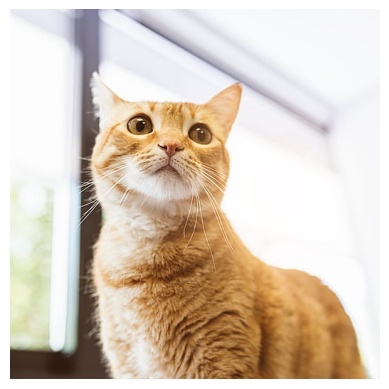

In [2]:
url = "https://www.anicura.es/cdn-cgi/image/f=auto,fit=cover,w=520,h=520,g=auto,sharpen=1/AdaptiveImages/powerinit/52437/_SNI2031.jpg?stamp=a2efc90c9d13cd9fdc0f5f7a2e3b2231238dc8cf"
response = requests.get(url)
response.raise_for_status()
image = Image.open(BytesIO(response.content))

plt.imshow(image)
plt.axis("off")
plt.show()

In [3]:
type(image)

PIL.JpegImagePlugin.JpegImageFile

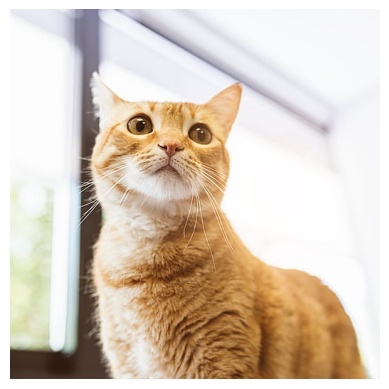

In [4]:
img = np.array(image)
plt.imshow(img)
plt.axis("off")
plt.show()

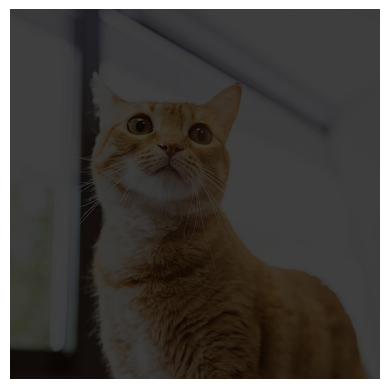

In [7]:
def contrast(img, new_m, new_M):
    old_m = img.min()
    old_M = img.max()

    img = (img - old_m) * ((new_M - new_m) / (old_M - old_m)) + new_m

    img = np.clip(img, 0, 255).astype(np.uint8)

    return img


new_img = contrast(img, 0, 64)
plt.imshow(new_img)
plt.axis("off")
plt.show()

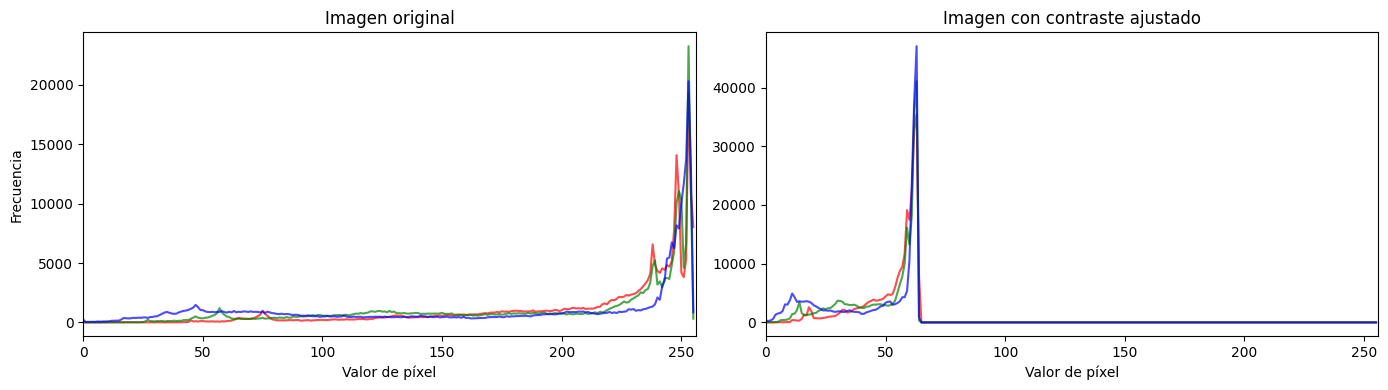

In [8]:
# Histograma de la imagen con contraste ajustado
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Imagen original
axes[0].set_title("Imagen original")
for i, color in enumerate(["red", "green", "blue"]):
    axes[0].plot(
        np.histogram(img[:, :, i], bins=256, range=(0, 256))[0], color=color, alpha=0.7
    )
axes[0].set_xlim([0, 256])
axes[0].set_xlabel("Valor de píxel")
axes[0].set_ylabel("Frecuencia")

# Imagen con contraste ajustado
axes[1].set_title("Imagen con contraste ajustado")
for i, color in enumerate(["red", "green", "blue"]):
    axes[1].plot(
        np.histogram(new_img[:, :, i], bins=256, range=(0, 256))[0],
        color=color,
        alpha=0.7,
    )
axes[1].set_xlim([0, 256])
axes[1].set_xlabel("Valor de píxel")

plt.tight_layout()
plt.show()

Dimensiones: (520, 520, 3)
Tipo de dato: uint8


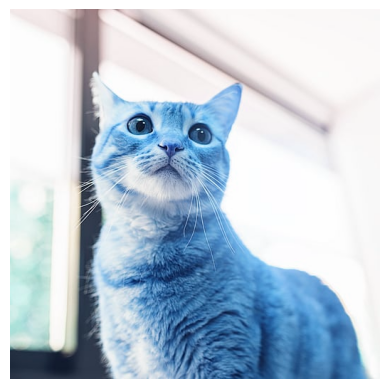

In [18]:
response = requests.get(url)
response.raise_for_status()

image_array = np.asarray(bytearray(response.content), dtype=np.uint8)
image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

print(f"Dimensiones: {image.shape}")
print(f"Tipo de dato: {image.dtype}")

plt.imshow(image)
plt.axis("off")
plt.show()

In [19]:
image.shape

(520, 520, 3)

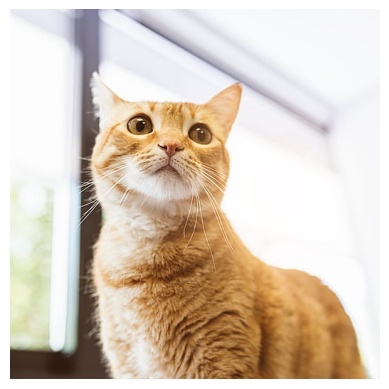

In [ ]:
image_rgb = cv2.cvtColor(
    image, cv2.COLOR_BGR2RGB
)  # Convertir BGR a RGB para matplotlib
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [21]:
type(image_rgb)

numpy.ndarray

In [22]:
print(f"Formato: {image.format}")
print(f"Tamaño: {image.size}")
print(f"Modo de color: {image.mode}")
print(f"Información extra: {image.info}")

AttributeError: 'numpy.ndarray' object has no attribute 'format'

In [23]:
img = image_rgb
img.shape

(520, 520, 3)

In [24]:
img[0]

array([[235, 235, 245],
       [235, 235, 245],
       [234, 234, 244],
       ...,
       [247, 246, 251],
       [247, 246, 251],
       [247, 246, 251]], dtype=uint8)

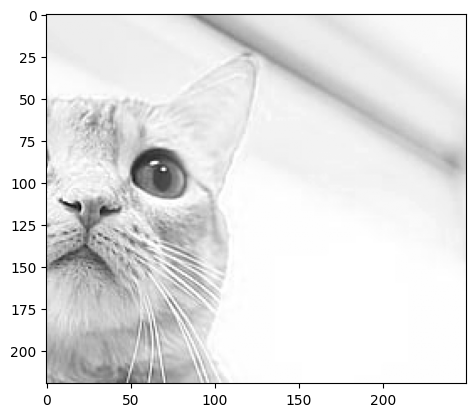

In [ ]:
plt.imshow(img[80:300, 200:450, 0], cmap="gray")
plt.show()

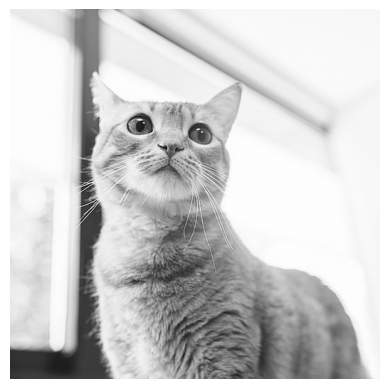

In [ ]:
# Convert the image to grayscale
gray_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

# Display the grayscale image
plt.imshow(gray_image, cmap="gray")
plt.axis("off")
plt.show()

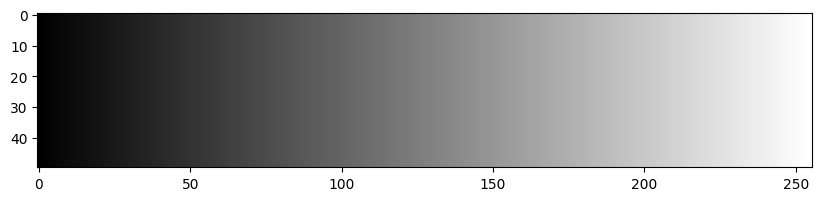

In [26]:
grayscale = np.linspace(0, 255, 256).astype(np.uint8)
gradient = np.tile(grayscale, (50, 1))

plt.figure(figsize=(10, 2))
plt.imshow(gradient, cmap="gray", aspect="auto")
plt.show()